# 🧠 EDA - Exploratory Data Analysis for Stance Classification
This notebook computes additional features and visualizes the distribution
of those features with respect to stance classes.

In [10]:
import pandas as pd
import re
import emoji
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load dataset
df = pd.read_csv("/Users/sergioparigi/Desktop/TESI/Tesi Sergio Final/stance_classification_dataset_final - stance_classification_dataset_final.csv")

# Create output folder for plots
Path("eda_plots").mkdir(parents=True, exist_ok=True)

In [11]:
# Add derived features
def count_emojis(text):
    return sum(1 for char in text if char in emoji.EMOJI_DATA)

def has_link(text):
    return 1 if re.search(r"http[s]?://", text) else 0

def count_words(text):
    return len(text.split())

def count_uppercase(text):
    return sum(1 for c in text if c.isupper())

df["EMOJI_COUNT"] = df["content"].apply(count_emojis)
df["LINK present"] = df["content"].apply(has_link)
df["NUM_WORDS"] = df["content"].apply(count_words)
df["NUM_UPPERCASE"] = df["content"].apply(count_uppercase)


from textblob import TextBlob

# Define function to calculate sentiment polarity
def get_sentiment(text):
    if pd.isna(text) or not isinstance(text, str):
        return 0.0
    return TextBlob(text).sentiment.polarity  # range: [-1, 1]

# Create new column
df["bio_sentiment"] = df["bio"].apply(get_sentiment)

# Save enriched dataset
df.to_csv("cleaned_stance_dataset_enriched.csv", index=False)

/var/folders/qq/95qwkbxs3zb9bw0w7n7tysmr0000gp/T/ipykernel_6009/875319815.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(["Promotional", "Neutral","Discouraging"])


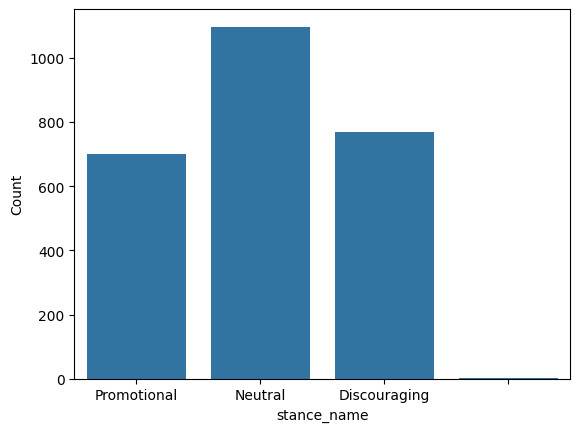

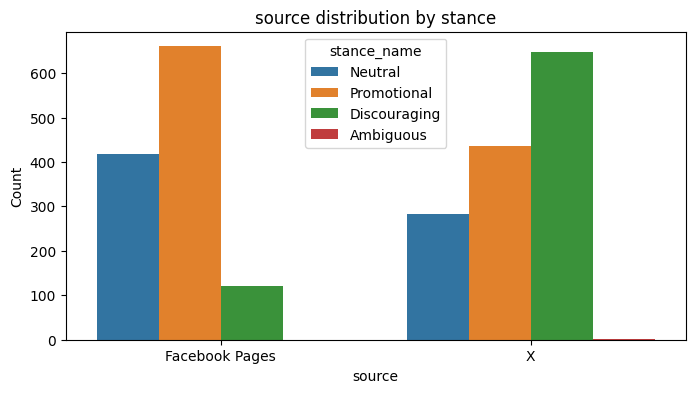

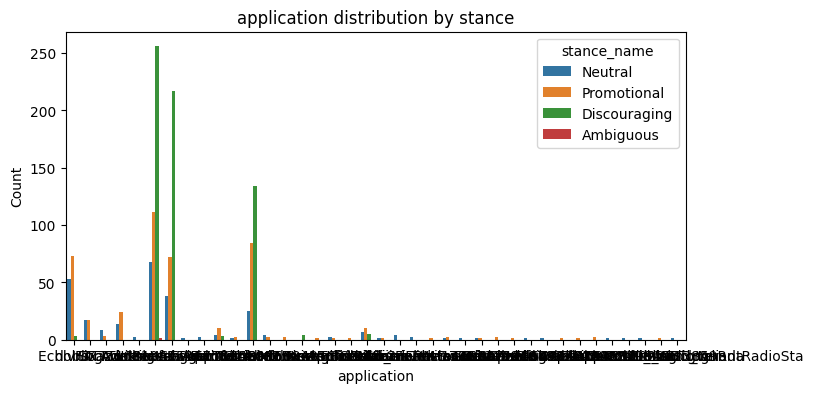

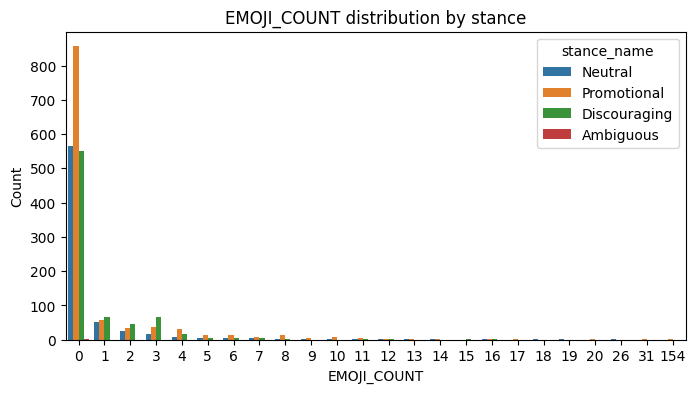

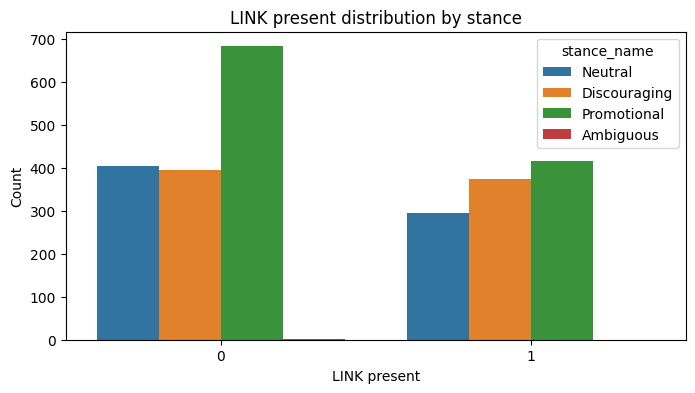

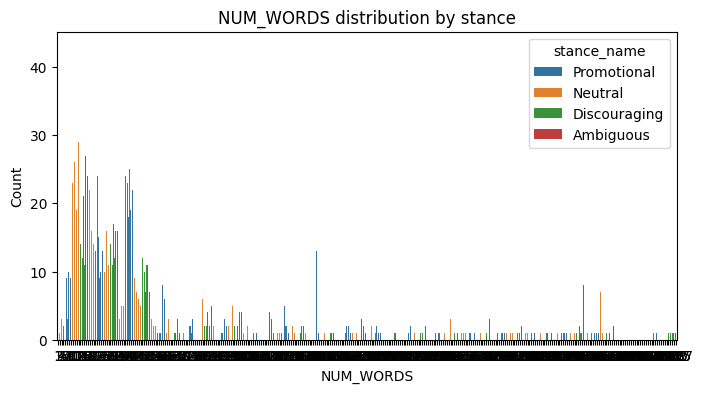

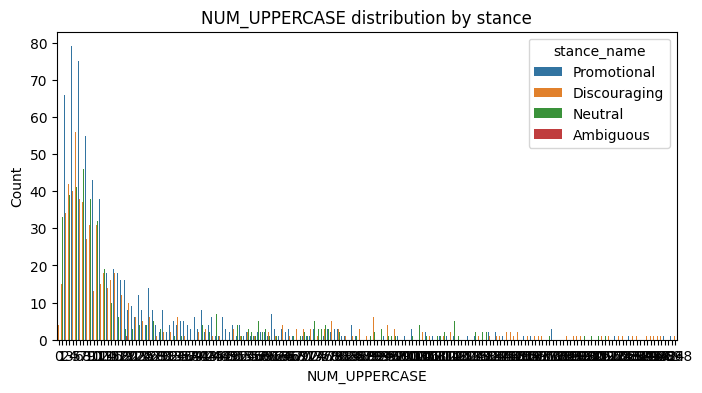

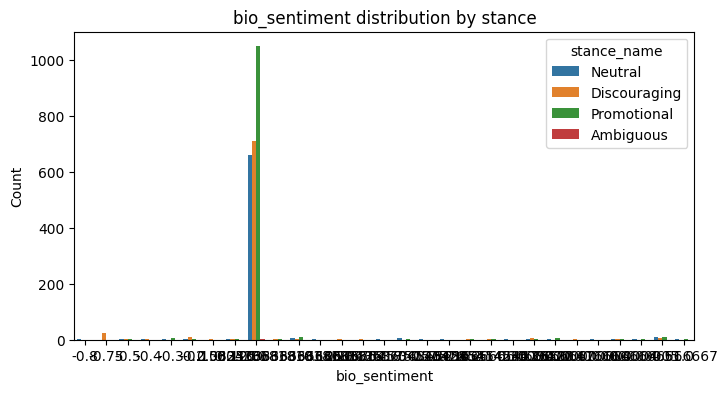

In [12]:
# Histogram plots
numeric_fields = ["source","application","EMOJI_COUNT", "LINK present", "NUM_WORDS", "NUM_UPPERCASE", "bio_sentiment"]
copy = df.copy()


g = sns.countplot(x=copy.stance_name)
g.set_xticklabels(["Promotional", "Neutral","Discouraging"])
g.set_xlabel("stance_name")
g.set_ylabel("Count")
plt.savefig("eda_plots/class_countplot", transparent=True)
plt.show()

for feature in numeric_fields:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=copy[feature],  hue=copy.stance_name)
    plt.title(f"{feature} distribution by stance")
    plt.xlabel(feature)
    plt.ylabel("Count")
    #plt.grid(True)
    #plt.tight_layout()
    plt.savefig(f"eda_plots/{feature}_by_stance.png")
    plt.show()
    plt.close()

In [4]:
# 📊 Plot histograms for all numeric columns grouped by label
numeric_fields = df.select_dtypes(include=["int64", "float64"]).drop(columns=["label"], errors='ignore').columns.tolist()
numeric_fields


['search',
 'title',
 'stance',
 'credibility',
 'credibility score',
 'tags',
 'sentiment',
 'sentiment by',
 'main emotion',
 'visibility',
 'ave',
 'duration',
 'circulation',
 'media reach',
 'media impressions',
 'social impressions',
 'region',
 'latitude',
 'longitude',
 'user latitude',
 'user longitude',
 'no. of followers',
 'no. of friends',
 'user views',
 'Job titles',
 'Companies',
 'Industries',
 'no. of comments',
 'no. of likes',
 'no. of shares',
 'no. of views',
 'Linkedin reactions',
 'Engagements_social shares',
 'user source id',
 'eRep',
 'CSR',
 'trust',
 'CX',
 'intensity',
 'climate change',
 'environmental impact',
 'biodiversity',
 'human rights',
 'labor practices',
 'community and society',
 'workforce protection',
 'local content',
 'transcribed_text',
 'no. of reposts',
 'stance.1',
 'EMOJI_COUNT',
 'LINK present',
 'NUM_WORDS',
 'NUM_UPPERCASE',
 'bio_sentiment']

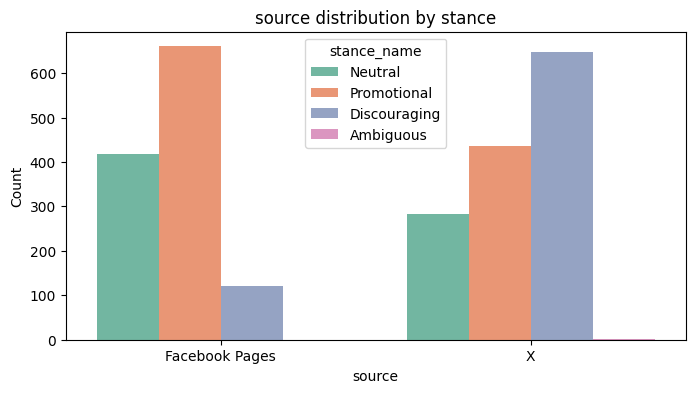

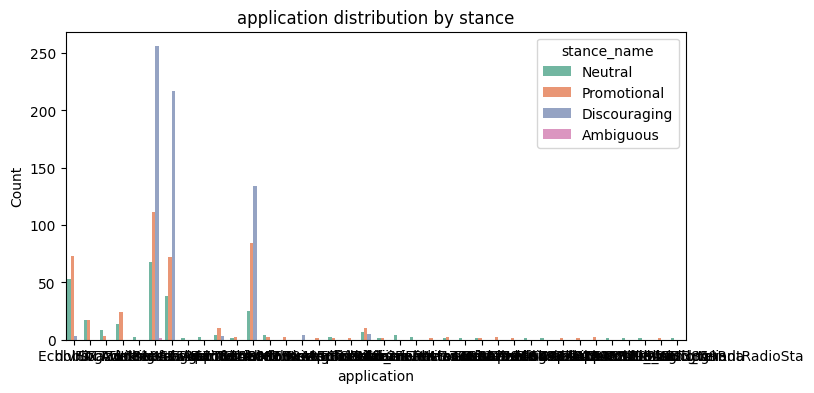

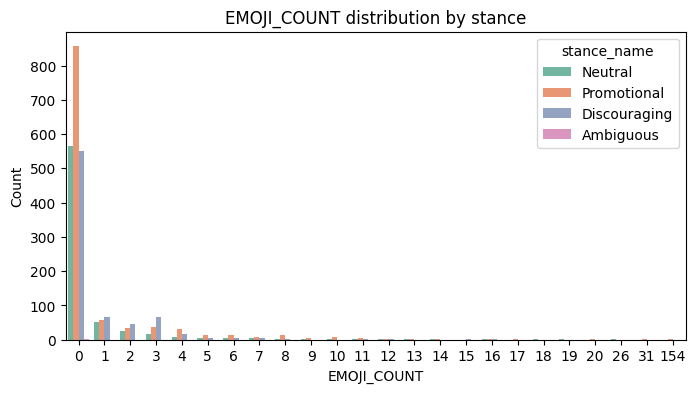

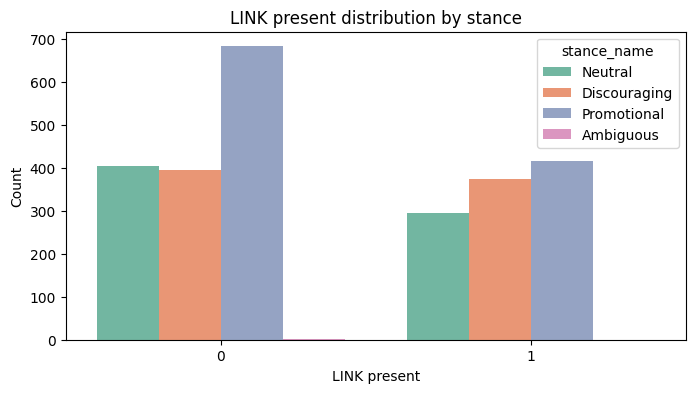

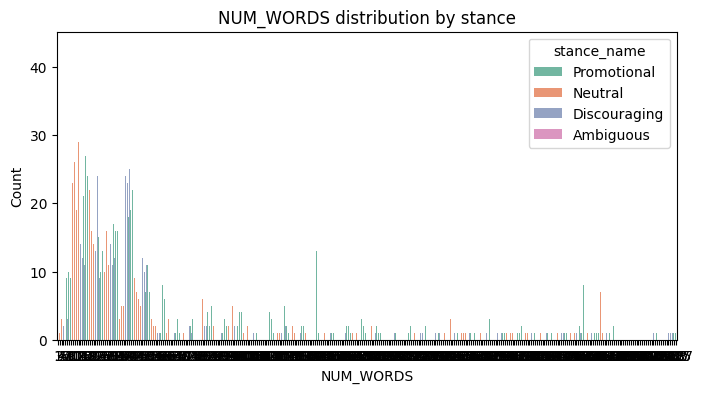

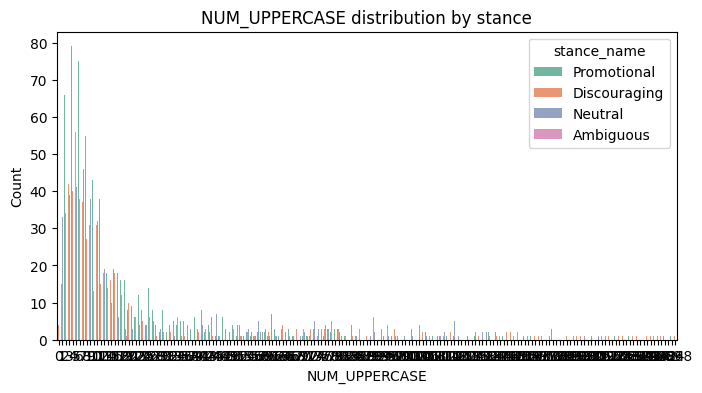

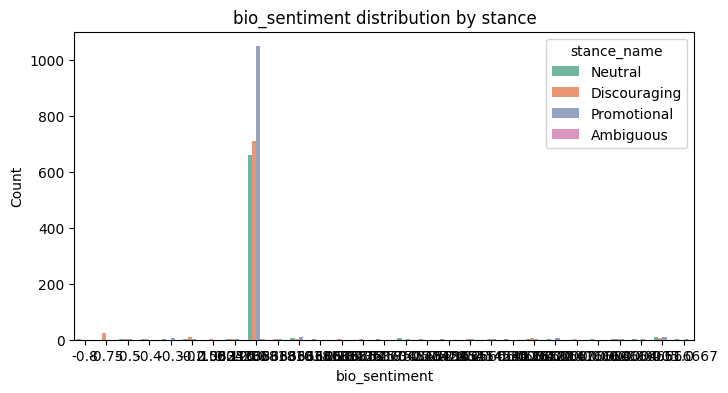

In [13]:
for feature in numeric_fields:
    plt.figure(figsize=(8, 4))
    sns.countplot( x=copy[feature], hue=copy.stance_name, palette="Set2")
    plt.title(f"{feature} distribution by stance")
    plt.xlabel(feature)
    plt.ylabel("Count")
    #plt.grid(True)
    #plt.tight_layout()
    plt.savefig(f"eda_plots/{feature}_by_stance.png")
    plt.show()
    plt.close()